# Predicting Price Moves with News Sentiment
## 📊 Task 1: Exploratory Data Analysis (EDA) on Financial News
#### **Goals:**
 - Understand headline characteristics
 - Identify key publishers
 - Analyze article publication trends
 - Visualize common topics in news headlines

### 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_style('whitegrid')  # Correct way

### 2. Load the Dataset

In [3]:
file_path = '../data/raw_analyst_ratings.csv'
df = pd.read_csv(file_path, parse_dates=['date'])

### 3. Basic Dataset Exploration

In [6]:
print("Data Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data:\n", df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB
None

Missing Values:
 Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Sample Data:
    Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4  

### 4. Create a column for headline length
This is for checking if the long headlines are more impactful or not

In [6]:
df['headline_length'] = df['headline'].apply(lambda x: len(str(x)))
df['headline_word_count'] = df['headline'].apply(lambda x: len(str(x).split()))

### 5. Plot Headline length distributions

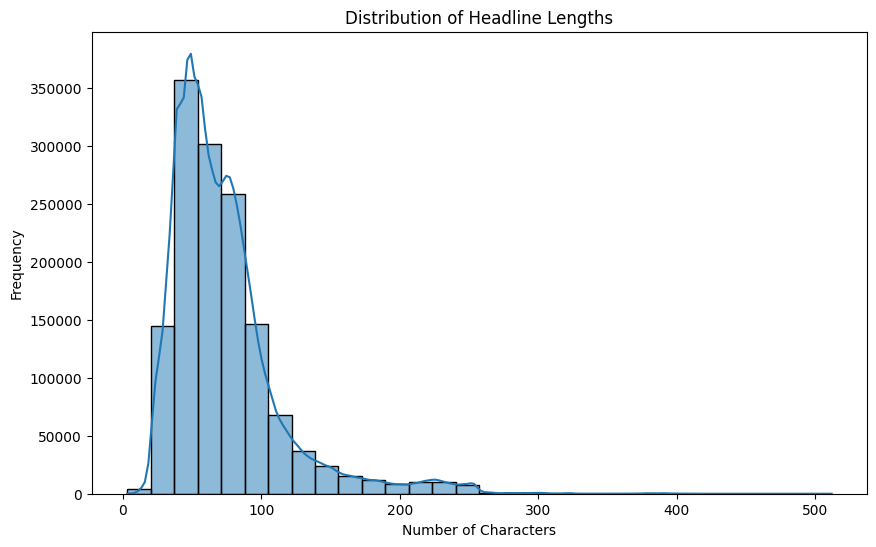

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=30, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

### 6. Publishre analysis

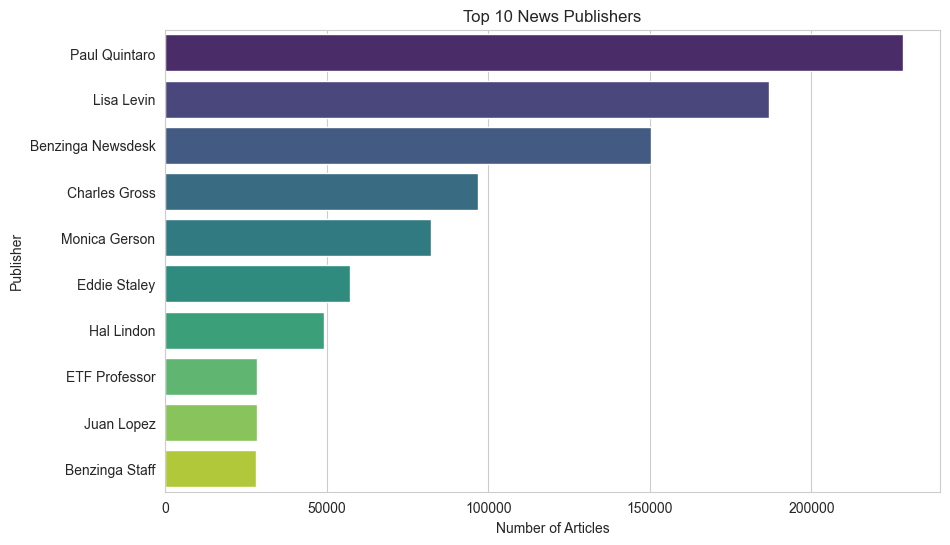

In [9]:
top_publishers = df['publisher'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')
plt.title('Top 10 News Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.show()

### 7. Articles Per Day

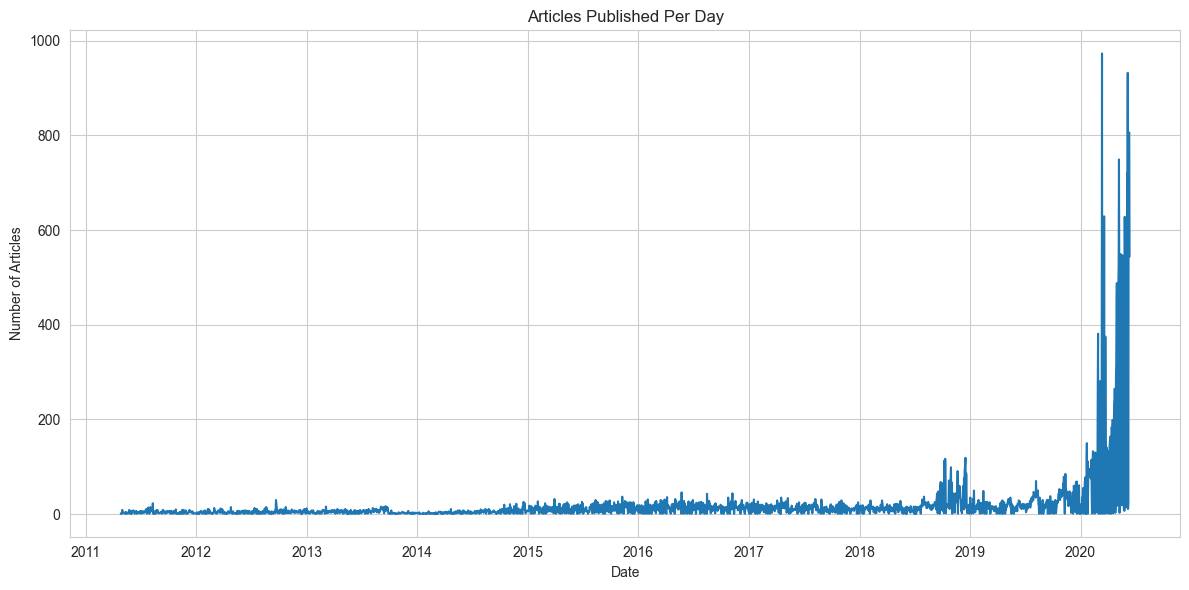

In [12]:
# 🛠 Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # Fixes any parsing issues

# 🗓 Extract just the date part (no time)
df['date_only'] = df['date'].dt.date

# 📊 Group by date to count articles per day
daily_articles = df.groupby('date_only').size()

# 📈 Plot number of articles published per day
plt.figure(figsize=(12, 6))
daily_articles.plot()
plt.title('Articles Published Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.tight_layout()
plt.show()


### Article Count by Stock

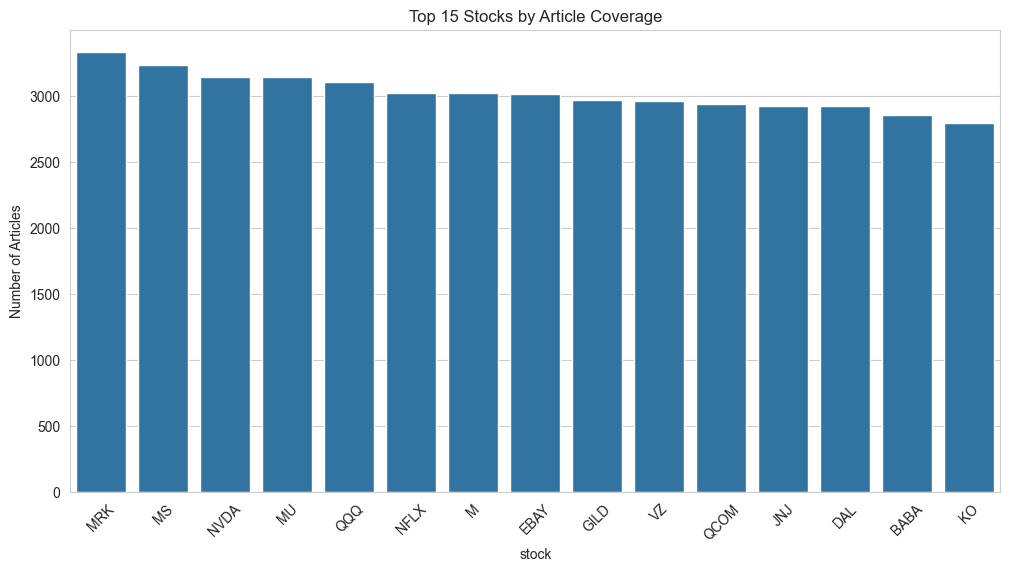

In [21]:
stock_counts = df['stock'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=stock_counts.index[:15], y=stock_counts.values[:15])
plt.xticks(rotation=45)
plt.title("Top 15 Stocks by Article Coverage")
plt.ylabel("Number of Articles")
plt.show()

### 8. Publish Time Distribution

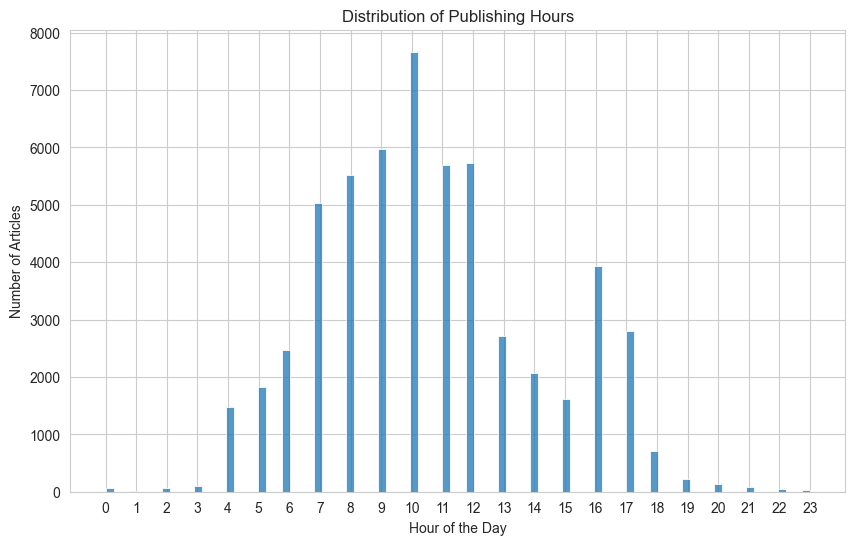

In [16]:
df['hour'] = df['date'].dt.hour
plt.figure(figsize=(10, 6))
sns.histplot(df['hour'])
plt.title('Distribution of Publishing Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Articles')
plt.xticks(range(0, 24))
plt.show()

### 9. Keyword Frequency

In [20]:
# Combine all headlines into one string and convert to lowercase
text = ' '.join(df['headline'].dropna()).lower()

# Extract words with 4 or more letters using regex
words = re.findall(r'\b[a-z]{4,}\b', text)

# Count word frequencies
word_freq = Counter(words)

# Convert to a DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])

# Sort by frequency in descending order
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# Show top 30 most frequent words
print(word_freq_df.head(10))

       Word  Frequency
0    stocks     161776
1      from     120805
2    market     120558
3    shares     114313
4   reports     108710
5    update      91723
6  earnings      87399
7      with      84257
8     sales      79645
9  benzinga      74516
